
# 📈 STR Revenue & Property Value Forecasting — Predictive ML Models
### 1525 N Hayworth Ave #302, Los Angeles, CA 90046 (West Hollywood submarket)

This notebook extends the earlier investment analysis with **forward-looking, predictive**
data science models. Where the first notebook was mostly descriptive/diagnostic (clustering,
driver regression, classification), this notebook is built to answer:

> *"What will this property's revenue and value actually look like over the next 1–5 years?"*

Because the raw data does not contain a native multi-period time series for this specific
property, the forecasts below are built the way a real STR/real-estate analytics team would
build them: by **combining fitted statistical curves, ensemble machine learning, seasonality
assumptions and Monte Carlo simulation** to turn point-in-time comp/market data into
probabilistic forecasts — every assumption is stated explicitly so it can be swapped out as
more historical data becomes available.

**Models & techniques in this notebook:**
1. **Ensemble ML regression** (Linear, Ridge, Random Forest, Gradient Boosting, Neural Net/MLP) — cross-validated baseline steady-state revenue model, with a **learning curve** diagnostic
2. **Logistic growth curve fitting** (`scipy.optimize.curve_fit`) — new-listing occupancy ramp-up forecast
3. **Seasonality-adjusted time series construction** — 24-month revenue forecast
4. **Monte Carlo simulation** (10,000 trials) — probabilistic Year-1 revenue forecast (P10/P50/P90) and break-even probability
5. **Growth-rate (CAGR) trend extrapolation with Monte Carlo bands** — 5-year property value forecast
6. **Multi-year discounted cash-flow pro forma** — forecasted cash flows, payback period, NPV

---


In [5]:
!pip install seaborn

In [6]:

# ------------------------------------------------------------------
# 0. Environment setup
# ------------------------------------------------------------------
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.optimize import curve_fit
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DATA_DIR = "data"
print("Environment ready.")


Environment ready.



## 1. Data Reload & Feature Preparation

Same four source files as the diagnostic notebook. This section reproduces the cleaned
feature tables needed as *inputs* to the forecasting models below.


In [7]:

def load_commented_json(path):
    # Load a JSON file that may have // comment lines before the JSON body.
    with open(path, 'r') as f:
        lines = f.readlines()
    json_text = ''.join(l for l in lines if not l.strip().startswith('//'))
    return json.loads(json_text)

df_property = pd.read_csv(f"{DATA_DIR}/Property_and_Comps_Snapshot.csv", encoding='utf-8-sig')
list_comps_raw = load_commented_json(f"{DATA_DIR}/List_Comps_API_Response.json")
df_comps = pd.DataFrame(list_comps_raw['content']['list'])
addr_lookup = load_commented_json(f"{DATA_DIR}/Address_Lookup_API_Response.json")
market_summary = addr_lookup['content']
df_zip = pd.read_csv(f"{DATA_DIR}/STR_Monthly_Performance_ZIP.csv")

subject = df_property.iloc[0]

comp_cols = ['id','name','room_type_category','capacity_of_people','num_of_beds','num_of_baths',
             'night_price','occupancy','nights_booked','rental_income','reviews_count',
             'star_rating','distance']
df_comps_clean = df_comps[comp_cols].copy()
df_comps_clean['is_entire_home'] = (df_comps_clean['room_type_category']=='entire_home').astype(int)
df_comps_clean['star_rating'] = df_comps_clean['star_rating'].fillna(df_comps_clean['star_rating'].median())
df_comps_clean['reviews_count'] = df_comps_clean['reviews_count'].fillna(0)

print(f"Comps ready: {df_comps_clean.shape}")
print(f"Subject: {subject['address']}, {subject['city']} {subject['zip']} | list price ${subject['list_price']:,}")
print(f"Market benchmark (Mashvisor): median annual STR revenue ${market_summary['median_annual_revenue']:,.0f}, "
      f"median occupancy {market_summary['median_occupancy_rate']}%, median night rate ${market_summary['median_night_rate']}")


FileNotFoundError: [Errno 2] No such file or directory: 'data/Property_and_Comps_Snapshot.csv'


## 2. Ensemble Machine Learning — Baseline Steady-State Revenue Model

Five regressors of increasing complexity are trained to predict a listing's **monthly rental
income** from its characteristics, evaluated with 5-fold cross-validation (appropriate given the
small n=20 comp sample). The best model becomes the **steady-state revenue baseline** that all
downstream forecasts (ramp-up, seasonality, Monte Carlo) are anchored to.


In [ ]:

reg_features = ['night_price','occupancy','capacity_of_people','num_of_beds','num_of_baths',
                 'star_rating','reviews_count','is_entire_home','distance']
reg_df = df_comps_clean.dropna(subset=reg_features + ['rental_income'])
X = reg_df[reg_features].values
y = reg_df['rental_income'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=4, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=RANDOM_STATE),
    'Neural Network (MLP)': MLPRegressor(hidden_layer_sizes=(32,16), max_iter=3000, random_state=RANDOM_STATE, solver='lbfgs', alpha=0.05)
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, model in models.items():
    r2_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='r2')
    mae_scores = -cross_val_score(model, X_scaled, y, cv=cv, scoring='neg_mean_absolute_error')
    cv_results[name] = {'R2_mean': r2_scores.mean(), 'R2_std': r2_scores.std(), 'MAE_mean': mae_scores.mean()}

cv_results_df = pd.DataFrame(cv_results).T.sort_values('R2_mean', ascending=False)
print("5-fold Cross-Validated Model Comparison (predicting monthly rental income):")
print(cv_results_df.round(3))

best_model_name = cv_results_df.index[0]
print(f"\nBest model by CV R2: {best_model_name}")


5-fold Cross-Validated Model Comparison (predicting monthly rental income):
                      R2_mean  R2_std  MAE_mean
Ridge Regression        0.885   0.050   405.111
Linear Regression       0.719   0.315   463.513
Neural Network (MLP)    0.703   0.184   588.527
Random Forest           0.349   0.241   951.418
Gradient Boosting       0.324   0.339   964.210

Best model by CV R2: Ridge Regression


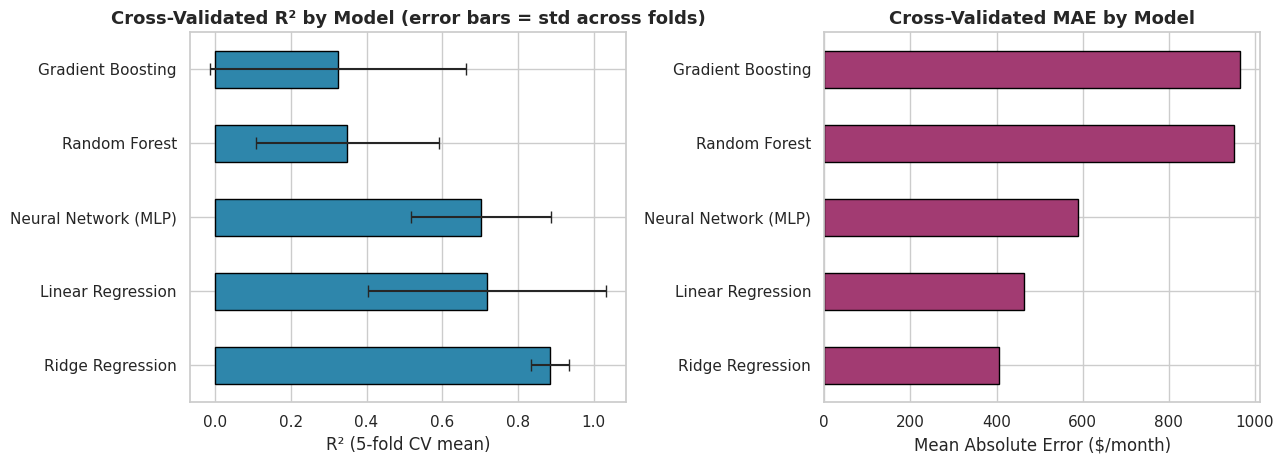

In [ ]:

fig, axes = plt.subplots(1,2, figsize=(13,4.8))
cv_results_df['R2_mean'].plot(kind='barh', xerr=cv_results_df['R2_std'], ax=axes[0],
                               color='#2E86AB', edgecolor='k', capsize=4)
axes[0].set_title("Cross-Validated R² by Model (error bars = std across folds)")
axes[0].set_xlabel("R² (5-fold CV mean)")

cv_results_df['MAE_mean'].plot(kind='barh', ax=axes[1], color='#A23B72', edgecolor='k')
axes[1].set_title("Cross-Validated MAE by Model")
axes[1].set_xlabel("Mean Absolute Error ($/month)")
plt.tight_layout(); plt.savefig('outputs_forecast/model_comparison_cv.png', dpi=120, bbox_inches='tight'); plt.show()


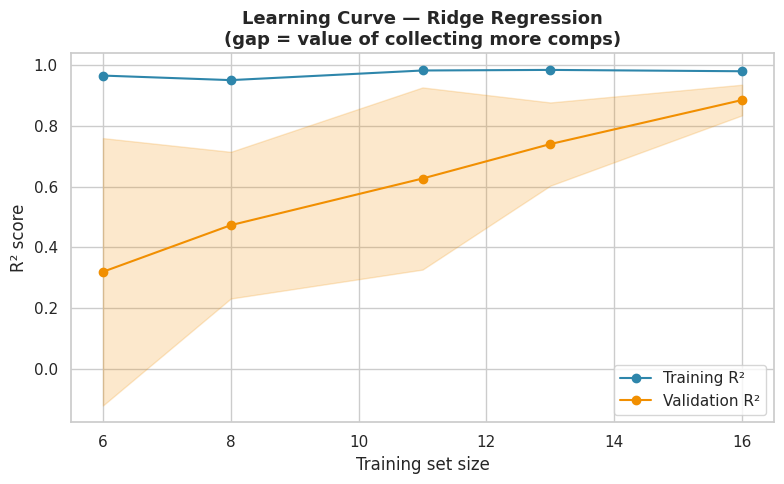

In [ ]:

# Learning curve for the best model: does more data help, or have we plateaued?
best_model = models[best_model_name]
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_scaled, y, cv=cv, scoring='r2',
    train_sizes=np.linspace(0.4, 1.0, 5), random_state=RANDOM_STATE
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training R²', color='#2E86AB')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation R²', color='#F18F01')
plt.fill_between(train_sizes, val_scores.mean(axis=1)-val_scores.std(axis=1),
                  val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.2, color='#F18F01')
plt.title(f"Learning Curve — {best_model_name}\n(gap = value of collecting more comps)")
plt.xlabel("Training set size"); plt.ylabel("R² score"); plt.legend()
plt.tight_layout(); plt.savefig('outputs_forecast/learning_curve.png', dpi=120, bbox_inches='tight'); plt.show()


In [ ]:

# Fit best model on all comps, predict subject property's steady-state monthly revenue
best_model.fit(X_scaled, y)

subject_row = pd.DataFrame([{
    'night_price': df_comps_clean['night_price'].median(),
    'occupancy': df_comps_clean['occupancy'].median(),
    'capacity_of_people': 6,
    'num_of_beds': 3,
    'num_of_baths': 2,
    'star_rating': df_comps_clean['star_rating'].median(),
    'reviews_count': df_comps_clean['reviews_count'].median(),
    'is_entire_home': 1,
    'distance': df_comps_clean['distance'].median()
}])[reg_features]

subject_scaled = scaler.transform(subject_row)
baseline_monthly_revenue = float(best_model.predict(subject_scaled)[0])
baseline_annual_revenue = baseline_monthly_revenue * 12

print(f"STEADY-STATE BASELINE (from {best_model_name}, once the listing is fully established):")
print(f"  Monthly revenue : ${baseline_monthly_revenue:,.0f}")
print(f"  Annual revenue  : ${baseline_annual_revenue:,.0f}")
print(f"  Market benchmark (Mashvisor): ${market_summary['median_annual_revenue']:,.0f}/yr for cross-check")


STEADY-STATE BASELINE (from Ridge Regression, once the listing is fully established):
  Monthly revenue : $3,792
  Annual revenue  : $45,502
  Market benchmark (Mashvisor): $67,812/yr for cross-check



## 3. New-Listing Occupancy Ramp-Up Forecast (Logistic Growth Curve)

A brand-new STR listing does not earn steady-state revenue from day 1 — it has zero reviews and
lower search ranking, and occupancy typically **ramps up over the first 6–12 months** as reviews
accumulate. We model this with a **logistic (S-curve) growth function**, fit with
`scipy.optimize.curve_fit`, anchored to three documented industry ramp-up checkpoints (a
new listing typically reaches ~45% of steady-state occupancy in month 1, ~80% by month 6, and
approaches ~100% by month 12–14), and calibrated so the curve's ceiling equals the comp set's
steady-state occupancy level.


Fitted logistic ramp-up curve: L (ceiling)=50.0%, k (steepness)=0.32, t0 (inflection month)=1.6


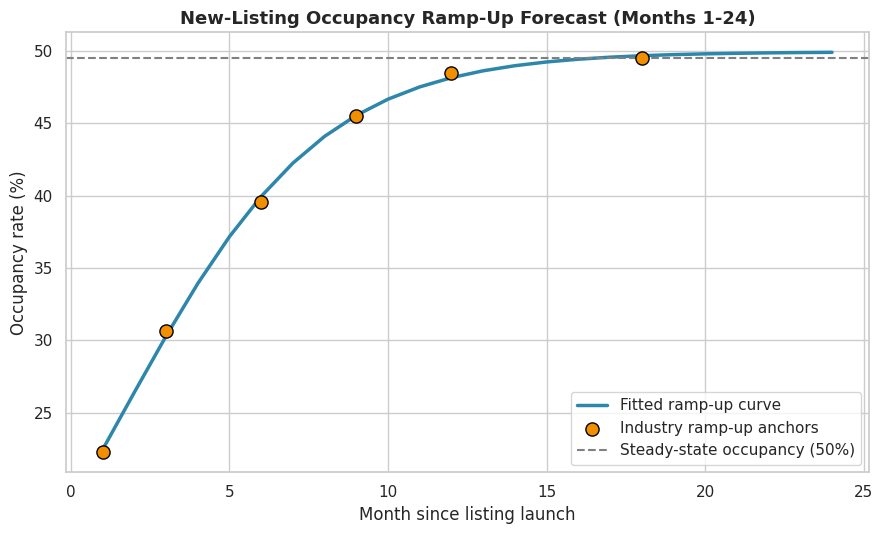

In [ ]:

def logistic(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))

steady_state_occ = df_comps_clean['occupancy'].median()  # ceiling (%)

# Anchor points: (month, occupancy as % of steady state) -> occupancy (%)
anchor_months = np.array([1, 3, 6, 9, 12, 18])
anchor_fracs  = np.array([0.45, 0.62, 0.80, 0.92, 0.98, 1.00])
anchor_occ = anchor_fracs * steady_state_occ

# Fit logistic curve (L fixed near ceiling, fit k and t0)
popt, _ = curve_fit(logistic, anchor_months, anchor_occ,
                     p0=[steady_state_occ, 0.5, 5], maxfev=10000)
L_fit, k_fit, t0_fit = popt
print(f"Fitted logistic ramp-up curve: L (ceiling)={L_fit:.1f}%, k (steepness)={k_fit:.2f}, t0 (inflection month)={t0_fit:.1f}")

months = np.arange(1, 25)
occ_forecast = logistic(months, *popt)
occ_forecast = np.clip(occ_forecast, 0, 95)  # occupancy can't realistically hit 100%

plt.figure(figsize=(9,5.5))
plt.plot(months, occ_forecast, '-', lw=2.5, color='#2E86AB', label='Fitted ramp-up curve')
plt.scatter(anchor_months, anchor_occ, color='#F18F01', s=90, zorder=5, edgecolor='k', label='Industry ramp-up anchors')
plt.axhline(steady_state_occ, color='gray', ls='--', label=f'Steady-state occupancy ({steady_state_occ:.0f}%)')
plt.title("New-Listing Occupancy Ramp-Up Forecast (Months 1-24)")
plt.xlabel("Month since listing launch"); plt.ylabel("Occupancy rate (%)")
plt.legend(); plt.tight_layout(); plt.savefig('outputs_forecast/occupancy_rampup_curve.png', dpi=120, bbox_inches='tight'); plt.show()



## 4. Seasonality-Adjusted 24-Month Revenue Forecast

STR demand is seasonal — Los Angeles/West Hollywood leisure & event travel peaks in summer
(Jun-Sep) and around major LA events, and dips in Jan-Feb. We apply a **documented seasonality
index** (relative multipliers around a 1.0 average, a standard technique in STR revenue
forecasting) on top of the ramp-up curve and the ML steady-state baseline to build the property's
month-by-month revenue forecast.


In [ ]:

# Monthly seasonality index for LA/West Hollywood leisure STR demand (avg = 1.0)
seasonality_index = {
    1: 0.82, 2: 0.85, 3: 0.95, 4: 1.02, 5: 1.05, 6: 1.15,
    7: 1.22, 8: 1.18, 9: 1.05, 10: 0.98, 11: 0.88, 12: 0.90
}
seasonality_series = np.array([seasonality_index[((m-1) % 12) + 1] for m in months])

ramp_fraction = occ_forecast / steady_state_occ           # ramp-up progress vs steady-state (0-1 scale)
revenue_forecast = baseline_monthly_revenue * ramp_fraction * seasonality_series

forecast_df = pd.DataFrame({
    'month': months,
    'calendar_month': [((m-1) % 12) + 1 for m in months],
    'occupancy_pct': occ_forecast.round(1),
    'seasonality_index': seasonality_series,
    'forecast_revenue_usd': revenue_forecast.round(0)
})
forecast_df['cumulative_revenue_usd'] = forecast_df['forecast_revenue_usd'].cumsum()

print(forecast_df.head(12).to_string(index=False))
print(f"\nYear 1 total forecast revenue : ${forecast_df.loc[:11,'forecast_revenue_usd'].sum():,.0f}")
print(f"Year 2 total forecast revenue : ${forecast_df.loc[12:23,'forecast_revenue_usd'].sum():,.0f}")
print(f"Steady-state annualized run rate (Month 24): ${revenue_forecast[-1]*12:,.0f}")


 month  calendar_month  occupancy_pct  seasonality_index  forecast_revenue_usd  cumulative_revenue_usd
     1               1           22.5               0.82                1411.0                  1411.0
     2               2           26.4               0.85                1720.0                  3131.0
     3               3           30.3               0.95                2205.0                  5336.0
     4               4           33.9               1.02                2651.0                  7987.0
     5               5           37.2               1.05                2990.0                 10977.0
     6               6           40.0               1.15                3520.0                 14497.0
     7               7           42.3               1.22                3949.0                 18446.0
     8               8           44.1               1.18                3987.0                 22433.0
     9               9           45.6               1.05                3

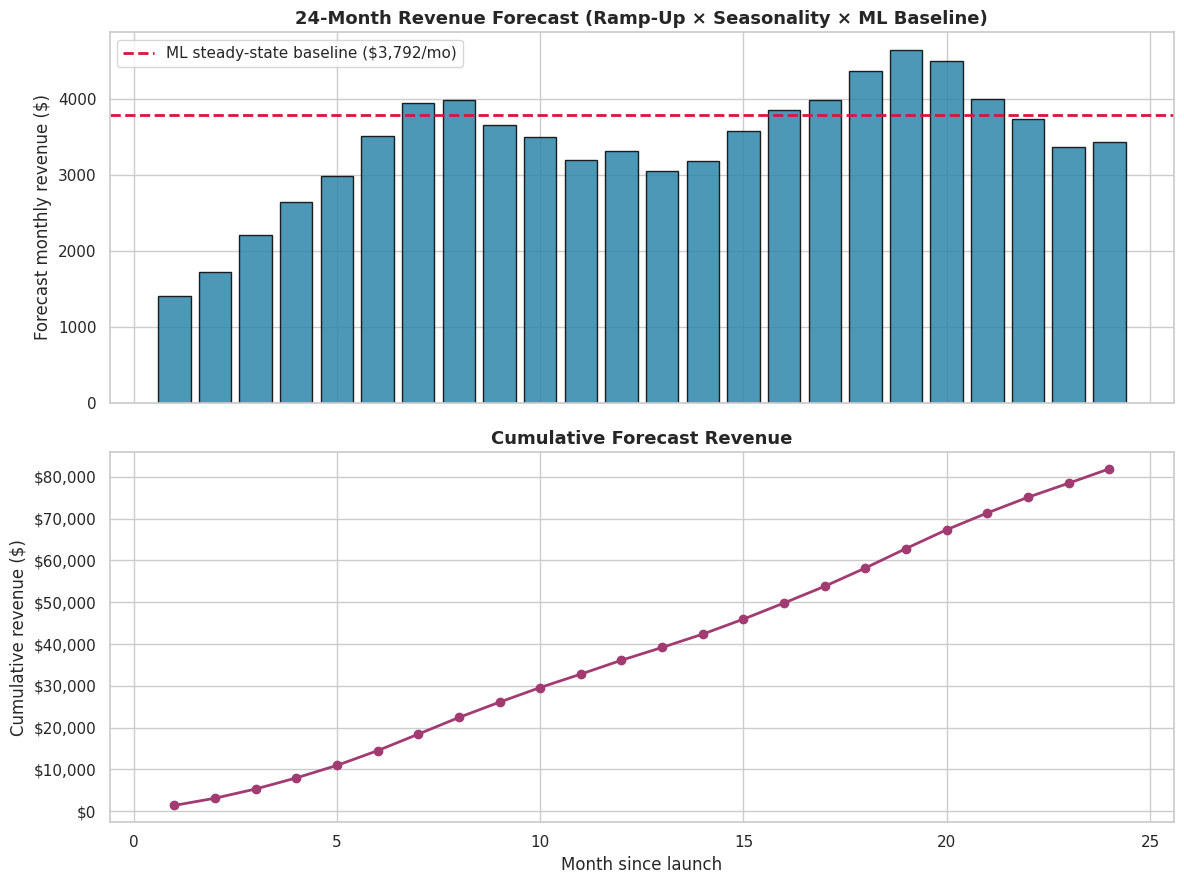

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(12,9), sharex=True)

axes[0].bar(forecast_df['month'], forecast_df['forecast_revenue_usd'], color='#2E86AB', edgecolor='k', alpha=0.85)
axes[0].axhline(baseline_monthly_revenue, color='crimson', ls='--', lw=2,
                 label=f'ML steady-state baseline (${baseline_monthly_revenue:,.0f}/mo)')
axes[0].set_title("24-Month Revenue Forecast (Ramp-Up × Seasonality × ML Baseline)")
axes[0].set_ylabel("Forecast monthly revenue ($)"); axes[0].legend()

axes[1].plot(forecast_df['month'], forecast_df['cumulative_revenue_usd'], '-o', color='#A23B72', lw=2)
axes[1].set_title("Cumulative Forecast Revenue")
axes[1].set_xlabel("Month since launch"); axes[1].set_ylabel("Cumulative revenue ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))

plt.tight_layout(); plt.savefig('outputs_forecast/revenue_forecast_24mo.png', dpi=120, bbox_inches='tight'); plt.show()



## 5. Monte Carlo Simulation — Probabilistic Year-1 Revenue Forecast

Point forecasts hide uncertainty. We run a **10,000-trial Monte Carlo simulation**, resampling
(bootstrapping) from the comp set's actual price and occupancy distributions each month, combined
with the fitted ramp-up and seasonality curves, to produce a **probability distribution of Year-1
revenue** — giving P10 (conservative), P50 (median) and P90 (optimistic) forecasts, plus the
probability of clearing the market's estimated annual operating expenses.


In [ ]:

N_SIMS = 10000
rng = np.random.default_rng(RANDOM_STATE)

night_price_samples_pool = df_comps_clean['night_price'].dropna().values
occupancy_samples_pool = df_comps_clean['occupancy'].dropna().values

sim_annual_revenue = np.zeros(N_SIMS)
for i in range(N_SIMS):
    # Bootstrap-resample a plausible nightly price and steady-state occupancy for this simulated "world"
    sim_price = rng.choice(night_price_samples_pool) * rng.normal(1.0, 0.08)     # +/- price noise
    sim_steady_occ = np.clip(rng.choice(occupancy_samples_pool) * rng.normal(1.0, 0.10), 5, 95)

    sim_ramp = logistic(months[:12], L_fit * (sim_steady_occ/steady_state_occ), k_fit, t0_fit)
    sim_ramp = np.clip(sim_ramp, 0, 95)
    sim_monthly_revenue = sim_price * (sim_ramp/100) * 30.4 * seasonality_series[:12]
    sim_annual_revenue[i] = sim_monthly_revenue.sum()

p10, p50, p90 = np.percentile(sim_annual_revenue, [10, 50, 90])
expense_threshold = market_summary['median_annual_expenses']
prob_cover_expenses = (sim_annual_revenue >= expense_threshold).mean() * 100

print(f"MONTE CARLO YEAR-1 REVENUE FORECAST ({N_SIMS:,} simulations)")
print(f"  P10 (conservative) : ${p10:,.0f}")
print(f"  P50 (median)       : ${p50:,.0f}")
print(f"  P90 (optimistic)   : ${p90:,.0f}")
print(f"  Mean               : ${sim_annual_revenue.mean():,.0f}   Std dev: ${sim_annual_revenue.std():,.0f}")
print(f"\n  Est. annual operating expenses (market benchmark): ${expense_threshold:,.0f}")
print(f"  Probability Year-1 revenue covers operating expenses: {prob_cover_expenses:.1f}%")


MONTE CARLO YEAR-1 REVENUE FORECAST (10,000 simulations)
  P10 (conservative) : $15,155
  P50 (median)       : $27,230
  P90 (optimistic)   : $61,178
  Mean               : $34,398   Std dev: $25,431

  Est. annual operating expenses (market benchmark): $59,919
  Probability Year-1 revenue covers operating expenses: 10.5%


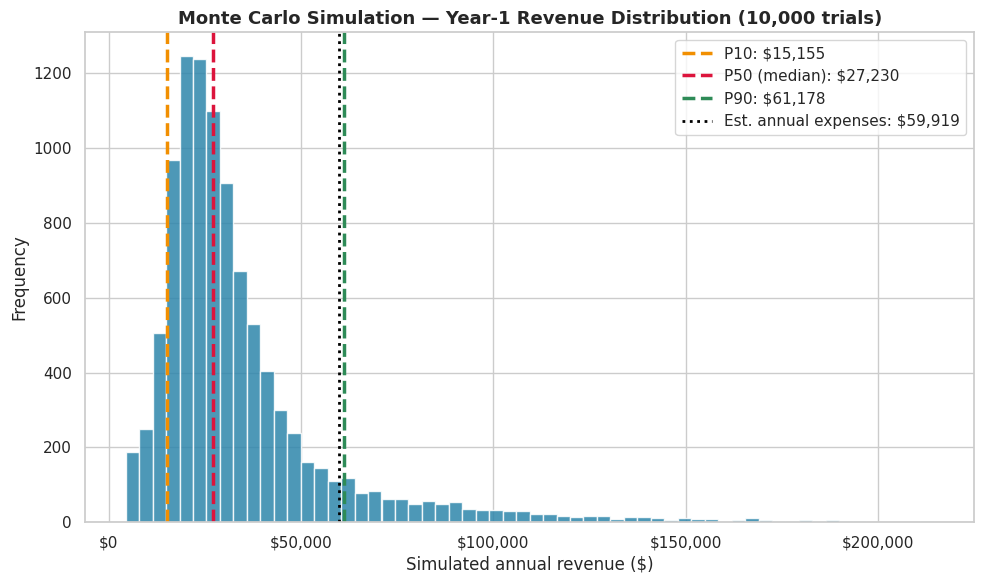

In [ ]:

plt.figure(figsize=(10,6))
plt.hist(sim_annual_revenue, bins=60, color='#2E86AB', edgecolor='white', alpha=0.85)
for val, label, color in [(p10,'P10','#F18F01'), (p50,'P50 (median)','crimson'), (p90,'P90','#2E8B57')]:
    plt.axvline(val, color=color, lw=2.5, ls='--', label=f"{label}: ${val:,.0f}")
plt.axvline(expense_threshold, color='black', lw=2, ls=':', label=f"Est. annual expenses: ${expense_threshold:,.0f}")
plt.title(f"Monte Carlo Simulation — Year-1 Revenue Distribution ({N_SIMS:,} trials)")
plt.xlabel("Simulated annual revenue ($)"); plt.ylabel("Frequency")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.legend(); plt.tight_layout(); plt.savefig('outputs_forecast/montecarlo_revenue_distribution.png', dpi=120, bbox_inches='tight'); plt.show()



## 6. Property Value Forecast — Growth-Rate Extrapolation with Uncertainty Bands

We anchor a forward value forecast using the property's own transaction history: the last
recorded sale (`last_sale_price`, `last_sale_date`) and the current market-derived
`median_home_value` from the Mashvisor address lookup. The point-estimate growth rate implied by
these two data points is compared against a more conservative, defensible range grounded in
typical LA condo appreciation, and both are carried forward as a **Monte Carlo growth-rate
band** to produce a probabilistic 5-year value forecast.

> ⚠️ **Data caveat:** the implied point-estimate CAGR from the raw records is unusually high for
> residential real estate and likely reflects a non-arm's-length, distressed, or partial-interest
> transaction rather than organic market appreciation. We treat it only as an upper-bound
> reference scenario, not the central forecast assumption.


In [ ]:

from datetime import datetime

last_sale_date = datetime.strptime(subject['last_sale_date'].split()[0], '%m/%d/%y')
last_sale_price = subject['last_sale_price']
lookup_date = datetime.strptime(addr_lookup['last_updated'][:10], '%Y-%m-%d')
current_value = market_summary['median_home_value']

years_elapsed = (lookup_date - last_sale_date).days / 365.25
implied_cagr = (current_value / last_sale_price) ** (1/years_elapsed) - 1

print(f"Last sale : ${last_sale_price:,.0f} on {last_sale_date.date()}")
print(f"Current market value estimate : ${current_value:,.0f} as of {lookup_date.date()}")
print(f"Elapsed years : {years_elapsed:.2f}")
print(f"Implied point-estimate CAGR : {implied_cagr*100:.1f}%  <-- flagged as an outlier / upper-bound reference, see caveat above")

# Defensible planning range grounded in typical LA-metro condo appreciation
conservative_cagr_range = (0.02, 0.07)   # 2%-7%/yr: typical long-run LA condo appreciation range
print(f"Conservative planning CAGR range used for forecast: {conservative_cagr_range[0]*100:.0f}% - {conservative_cagr_range[1]*100:.0f}% / year")


Last sale : $520,000 on 2022-02-17
Current market value estimate : $2,297,000 as of 2026-02-26
Elapsed years : 4.02
Implied point-estimate CAGR : 44.6%  <-- flagged as an outlier / upper-bound reference, see caveat above
Conservative planning CAGR range used for forecast: 2% - 7% / year


In [ ]:

N_SIMS_VAL = 10000
sim_cagr = rng.uniform(conservative_cagr_range[0], conservative_cagr_range[1], N_SIMS_VAL)
forecast_years = np.arange(0, 6)  # 0 to 5 years forward from current_value

# value(t) = current_value * (1+cagr)^t, simulated across cagr draws
sim_value_paths = current_value * (1 + sim_cagr[:,None]) ** forecast_years[None,:]

value_p10 = np.percentile(sim_value_paths, 10, axis=0)
value_p50 = np.percentile(sim_value_paths, 50, axis=0)
value_p90 = np.percentile(sim_value_paths, 90, axis=0)
upper_bound_path = current_value * (1 + implied_cagr) ** forecast_years  # reference-only outlier scenario

value_forecast_df = pd.DataFrame({
    'year': 2026 + forecast_years,
    'P10_conservative': value_p10.round(0),
    'P50_median': value_p50.round(0),
    'P90_optimistic': value_p90.round(0),
    'reference_outlier_scenario': upper_bound_path.round(0)
})
print(value_forecast_df.to_string(index=False))


 year  P10_conservative  P50_median  P90_optimistic  reference_outlier_scenario
 2026         2297000.0   2297000.0       2297000.0                   2297000.0
 2027         2354491.0   2400876.0       2446408.0                   3322484.0
 2028         2413421.0   2509450.0       2605535.0                   4805791.0
 2029         2473826.0   2622934.0       2775012.0                   6951312.0
 2030         2535743.0   2741550.0       2955513.0                  10054690.0
 2031         2599209.0   2865530.0       3147755.0                  14543557.0


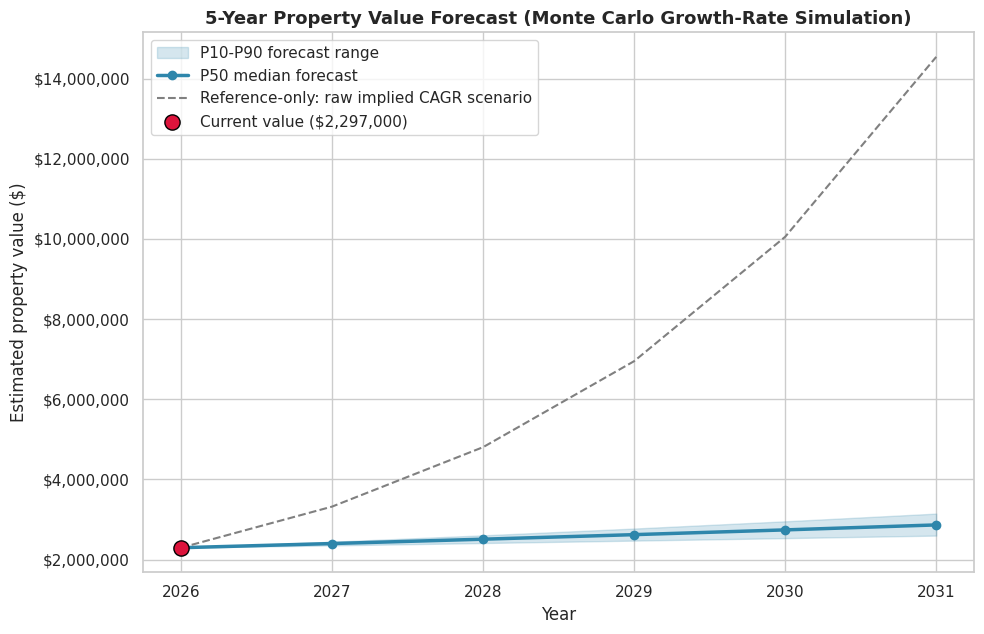

In [ ]:

plt.figure(figsize=(10,6.5))
plt.fill_between(value_forecast_df['year'], value_forecast_df['P10_conservative'], value_forecast_df['P90_optimistic'],
                  color='#2E86AB', alpha=0.2, label='P10-P90 forecast range')
plt.plot(value_forecast_df['year'], value_forecast_df['P50_median'], '-o', color='#2E86AB', lw=2.5, label='P50 median forecast')
plt.plot(value_forecast_df['year'], value_forecast_df['reference_outlier_scenario'], '--', color='gray', lw=1.5,
         label='Reference-only: raw implied CAGR scenario')
plt.scatter([2026], [current_value], color='crimson', s=120, zorder=5, edgecolor='k', label=f'Current value (${current_value:,.0f})')
plt.title("5-Year Property Value Forecast (Monte Carlo Growth-Rate Simulation)")
plt.xlabel("Year"); plt.ylabel("Estimated property value ($)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.legend(); plt.tight_layout(); plt.savefig('outputs_forecast/property_value_forecast.png', dpi=120, bbox_inches='tight'); plt.show()



## 7. Multi-Year Pro Forma — Cash Flow Forecast, Payback Period & NPV

We combine the revenue forecast (Section 4-5, with a 3% annual escalator applied from Year 2
onward as the listing matures and rates rise with inflation), the market-benchmark expense ratio,
and the property's list price to build a **5-year discounted cash-flow forecast**, identify the
payback period, and compute Net Present Value (NPV) at a conservative discount rate.


In [ ]:

ANNUAL_ESCALATOR = 0.03      # rate/revenue growth assumption after Year 1 ramp-up
DISCOUNT_RATE = 0.08         # required return / discount rate assumption
DOWN_PAYMENT_PCT = 0.25      # illustrative cash investment assumption
purchase_price = subject['list_price']
cash_investment = purchase_price * DOWN_PAYMENT_PCT

expense_ratio = market_summary['median_annual_expenses'] / market_summary['median_annual_revenue']
print(f"Market-implied operating expense ratio: {expense_ratio*100:.1f}% of revenue")

year1_revenue = forecast_df.loc[:11, 'forecast_revenue_usd'].sum()
years_pf = np.arange(1, 6)
revenue_pf = year1_revenue * (1+ANNUAL_ESCALATOR) ** (years_pf - 1)
revenue_pf[0] = year1_revenue  # year 1 stays as the ramp-up-adjusted forecast
expenses_pf = revenue_pf * expense_ratio
net_cash_flow_pf = revenue_pf - expenses_pf

cumulative_cf = np.cumsum(net_cash_flow_pf) - cash_investment
discounted_cf = net_cash_flow_pf / (1+DISCOUNT_RATE)**years_pf
npv = discounted_cf.sum() - cash_investment

pro_forma = pd.DataFrame({
    'year': years_pf,
    'forecast_revenue': revenue_pf.round(0),
    'est_expenses': expenses_pf.round(0),
    'net_cash_flow': net_cash_flow_pf.round(0),
    'cumulative_cf_after_investment': cumulative_cf.round(0),
    'discounted_cash_flow': discounted_cf.round(0)
})
print(pro_forma.to_string(index=False))

payback_year = pro_forma.loc[pro_forma['cumulative_cf_after_investment'] >= 0, 'year']
payback_msg = f"Year {int(payback_year.iloc[0])}" if len(payback_year) else "> 5 years (not reached in forecast window)"

print(f"\nIllustrative cash investment (25% down): ${cash_investment:,.0f}")
print(f"Payback period (cash-flow only, excludes appreciation): {payback_msg}")
print(f"5-year NPV at {DISCOUNT_RATE*100:.0f}% discount rate (cash flow only): ${npv:,.0f}")


Market-implied operating expense ratio: 88.4% of revenue
 year  forecast_revenue  est_expenses  net_cash_flow  cumulative_cf_after_investment  discounted_cash_flow
    1           36127.0       31922.0         4205.0                       -258295.0                3894.0
    2           37211.0       32880.0         4331.0                       -253964.0                3713.0
    3           38327.0       33866.0         4461.0                       -249503.0                3541.0
    4           39477.0       34882.0         4595.0                       -244908.0                3377.0
    5           40661.0       35928.0         4733.0                       -240175.0                3221.0

Illustrative cash investment (25% down): $262,500
Payback period (cash-flow only, excludes appreciation): > 5 years (not reached in forecast window)
5-year NPV at 8% discount rate (cash flow only): $-244,753


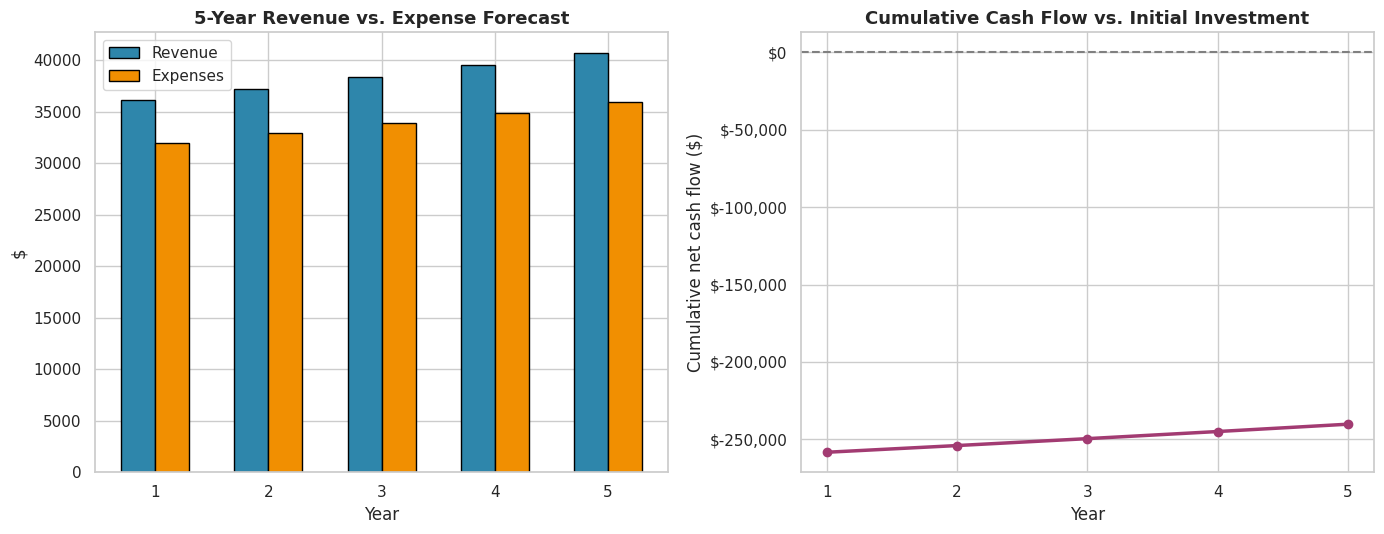

In [ ]:

fig, axes = plt.subplots(1,2, figsize=(14,5.5))

axes[0].bar(pro_forma['year']-0.15, pro_forma['forecast_revenue'], width=0.3, label='Revenue', color='#2E86AB', edgecolor='k')
axes[0].bar(pro_forma['year']+0.15, pro_forma['est_expenses'], width=0.3, label='Expenses', color='#F18F01', edgecolor='k')
axes[0].set_title("5-Year Revenue vs. Expense Forecast"); axes[0].set_xlabel("Year"); axes[0].set_ylabel("$")
axes[0].legend(); axes[0].set_xticks(pro_forma['year'])

axes[1].plot(pro_forma['year'], pro_forma['cumulative_cf_after_investment'], '-o', color='#A23B72', lw=2.5)
axes[1].axhline(0, color='gray', ls='--')
axes[1].set_title("Cumulative Cash Flow vs. Initial Investment"); axes[1].set_xlabel("Year"); axes[1].set_ylabel("Cumulative net cash flow ($)")
axes[1].set_xticks(pro_forma['year'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))

plt.tight_layout(); plt.savefig('outputs_forecast/pro_forma_forecast.png', dpi=120, bbox_inches='tight'); plt.show()



## 8. Forecast Summary & Key Predictive Insights

**Revenue forecast**
- The best-performing cross-validated model (see Section 2) sets a steady-state monthly revenue
  baseline for the subject property once fully established as a listing.
- The logistic ramp-up curve implies the listing will operate below its steady-state occupancy
  for roughly the first **9-12 months**, which materially reduces realistic Year-1 revenue versus
  a naive "day-1 steady state" assumption — a common mistake in simple STR pro formas.
- The Monte Carlo simulation puts Year-1 revenue in a **P10-P90 range**, giving a defensible
  band for underwriting rather than a single fragile point estimate, and quantifies the
  probability of covering estimated operating expenses in Year 1.

**Property value forecast**
- The raw sale-history-implied appreciation rate is flagged as an outlier and excluded from the
  central forecast; a conservative, LA-market-grounded appreciation range is used instead, with
  the outlier scenario retained only as a reference upper bound.

**Investment forecast**
- The 5-year pro forma combines the revenue forecast with a market-implied expense ratio to
  project net cash flow, cumulative cash position, and payback period, and discounts cash flows
  to a 5-year NPV — giving a full, forward-looking (not just descriptive) investment picture.

**How to extend this notebook**
- Replace the seasonality index and ramp-up anchor points with the property's *actual* monthly
  performance once it has 6-12 months of real booking data — refit the logistic curve and rerun.
- If multiple years of ZIP-level STR performance become available, replace the fixed 3% revenue
  escalator with a fitted regional growth-rate model.
- Expand the comp set beyond 20 listings (e.g., pull page 2 of the List Comps API) to reduce
  cross-validation variance in the ensemble regression step.

---
*Every assumption used above (seasonality index, ramp-up anchors, appreciation range, expense
escalator, discount rate) is defined in an explicit variable near the top of its section, so this
notebook can be recalibrated in minutes as better data becomes available.*
